# Exploring `data/pubmed/papers.jsonl`

Each line of the file is a JSON dict that can be passed directly to the `Paper` pydantic model defined in `src/paper_parser/shared/schemas.py`. A `Paper` has:

- **Identifiers**: `paper_id` (primary) and `all_paper_ids` (PMC / PMID / DOI).
- **Metadata**: `paper_type`, `pub_date` (`Date` with year/month/day), `subjects`.
- **Content tree**: `title` (a `Sentence`), `abstract` and `maintext` (lists of `Content` nodes — `Section` / `Paragraph` / `Sentence` / `Figure`). Every node has a hierarchical `content_id` like `["maintext", 3, 0, 1]`.
- **Bibliography**: dict of `rid -> BibEntry` with associated IDs.
- **References**: `Sentence.refs` are inline cross-references (to figures, bib entries, etc.) with character offsets.

The file is very large (hundreds of GB), so we stream it line-by-line rather than loading it into memory.

In [1]:
import json
import os
from collections import Counter
from multiprocessing import Pool
from pathlib import Path
import matplotlib.pyplot as plt
from datetime import date

from tqdm.auto import tqdm

DATA_PATH = Path("../data/pubmed/papers.jsonl")
assert DATA_PATH.exists(), f"Missing {DATA_PATH.resolve()}"

print(f"File: {DATA_PATH.resolve()}")
print(f"Size: {DATA_PATH.stat().st_size / 1e9:.1f} GB")

File: /media/jessica/bigdata/paper_parser/data/pubmed/papers.jsonl
Size: 437.2 GB


## Statistics

In [2]:
def _count_tree(nodes: list, c: dict, depth: int = 0) -> None:
    """Walk a list of content-node dicts, updating counters in place.

    Section titles are counted as sentences (they are `Sentence` objects in the schema).
    """
    for n in nodes:
        ct = n.get("content_type")
        if depth > c["depth"]:
            c["depth"] = depth
        if ct == "section":
            c["sec"] += 1
            title = n.get("title") or {}
            c["sent"] += 1
            c["chars"] += len(title.get("text") or "")
            for r in title.get("refs") or []:
                rt = r.get("ref_type")
                c["ref_types"][rt] = c["ref_types"].get(rt, 0) + 1
            _count_tree(n.get("contents") or [], c, depth + 1)
        elif ct == "paragraph":
            c["par"] += 1
            _count_tree(n.get("contents") or [], c, depth + 1)
        elif ct == "sentence":
            c["sent"] += 1
            c["chars"] += len(n.get("text") or "")
            refs = n.get("refs") or []
            if refs:
                c["sents_with_refs"] += 1
            for r in refs:
                rt = r.get("ref_type")
                c["ref_types"][rt] = c["ref_types"].get(rt, 0) + 1
        elif ct == "figure":
            c["fig"] += 1
            _count_tree(n.get("contents") or [], c, depth + 1)


def _new_tree_counter() -> dict:
    return {
        "sec": 0, "par": 0, "sent": 0, "fig": 0,
        "depth": 0, "chars": 0, "sents_with_refs": 0, "ref_types": {},
    }


def _new_agg() -> dict:
    return {
        "n": 0,
        "parse_errors": 0,
        "paper_type": Counter(),
        "year": Counter(),
        "subjects": Counter(),
        "primary_id_type": Counter(),
        "id_presence": Counter(),
        "id_combos": Counter(),
        "keys": Counter(),
        "abs_sec": Counter(), "abs_par": Counter(), "abs_sent": Counter(),
        "abs_fig": Counter(), "abs_depth": Counter(), "abs_chars_sum": 0,
        "main_sec": Counter(), "main_par": Counter(), "main_sent": Counter(),
        "main_fig": Counter(), "main_depth": Counter(), "main_chars_sum": 0,
        "bib_size": Counter(),
        "bib_with_ids_sum": 0,
        "ref_types": Counter(),
        "sents_with_refs_sum": 0,
        "n_sentences_total": 0,
        "empty_abstract": 0,
        "empty_maintext": 0,
    }


def process_chunk(lines: list[str]) -> dict:
    """Aggregate stats over a chunk of raw JSONL lines. Runs in a worker process."""
    agg = _new_agg()
    for line in lines:
        try:
            raw = json.loads(line)
        except Exception:
            agg["parse_errors"] += 1
            continue

        agg["n"] += 1
        agg["keys"].update(raw.keys())
        agg["paper_type"][raw.get("paper_type")] += 1
        agg["year"][(raw.get("pub_date") or {}).get("year")] += 1
        agg["subjects"].update(raw.get("subjects") or [])

        pid = raw.get("paper_id") or {}
        agg["primary_id_type"][pid.get("id_type")] += 1
        id_types = tuple(sorted(
            {i["id_type"] for i in (raw.get("all_paper_ids") or []) if i.get("value")}
        ))
        agg["id_combos"][id_types] += 1
        for t in id_types:
            agg["id_presence"][t] += 1

        abs_c = _new_tree_counter()
        _count_tree(raw.get("abstract") or [], abs_c)
        main_c = _new_tree_counter()
        _count_tree(raw.get("maintext") or [], main_c)

        for region, c in (("abs", abs_c), ("main", main_c)):
            agg[f"{region}_sec"][c["sec"]] += 1
            agg[f"{region}_par"][c["par"]] += 1
            agg[f"{region}_sent"][c["sent"]] += 1
            agg[f"{region}_fig"][c["fig"]] += 1
            agg[f"{region}_depth"][c["depth"]] += 1
            agg[f"{region}_chars_sum"] += c["chars"]

        if abs_c["sent"] == 0:
            agg["empty_abstract"] += 1
        if main_c["sent"] == 0:
            agg["empty_maintext"] += 1

        for k, v in abs_c["ref_types"].items():
            agg["ref_types"][k] += v
        for k, v in main_c["ref_types"].items():
            agg["ref_types"][k] += v
        agg["sents_with_refs_sum"] += abs_c["sents_with_refs"] + main_c["sents_with_refs"]
        agg["n_sentences_total"] += abs_c["sent"] + main_c["sent"]

        bib = raw.get("bibliography") or {}
        agg["bib_size"][len(bib)] += 1
        agg["bib_with_ids_sum"] += sum(1 for e in bib.values() if e.get("all_paper_ids"))

    return agg


def merge_agg(a: dict, b: dict) -> dict:
    """Merge b into a in place."""
    for k, v in b.items():
        if isinstance(v, Counter):
            a[k].update(v)
        elif isinstance(v, list):
            a[k].extend(v)
        else:
            a[k] = a.get(k, 0) + v
    return a


def iter_chunks(path: Path, chunk_size: int, limit: int | None = None):
    """Yield batches of at most `chunk_size` raw lines from `path`.
    Stops after `limit` lines total if `limit` is not None."""
    count = 0
    with path.open("r") as f:
        batch: list[str] = []
        for line in f:
            if limit is not None and count >= limit:
                break
            batch.append(line)
            count += 1
            if len(batch) >= chunk_size:
                yield batch
                batch = []
        if batch:
            yield batch

In [3]:
# Tune these. Set LIMIT to e.g. 100_000 for a quick end-to-end test, None for full file.
LIMIT: int | None = None
N_WORKERS: int = max(1, (os.cpu_count() or 4) - 2)
CHUNK_SIZE: int = 500

print(f"Running on {N_WORKERS} workers, chunk_size={CHUNK_SIZE}, limit={LIMIT}")

agg = _new_agg()
with Pool(N_WORKERS) as pool:
    for partial in tqdm(
        pool.imap_unordered(process_chunk, iter_chunks(DATA_PATH, CHUNK_SIZE, LIMIT)),
        desc="chunks",
    ):
        merge_agg(agg, partial)

print(f"\nDone. Papers processed: {agg['n']:,}  |  parse errors: {agg['parse_errors']:,}")

Running on 22 workers, chunk_size=500, limit=None


chunks: 0it [00:00, ?it/s]


Done. Papers processed: 7,533,058  |  parse errors: 0


In [4]:
def hist_mean(c: Counter) -> float:
    vals = [(k, v) for k, v in c.items() if k is not None]
    n = sum(v for _, v in vals)
    return (sum(k * v for k, v in vals) / n) if n else 0.0


def hist_quantile(c: Counter, q: float):
    vals = sorted(((k, v) for k, v in c.items() if k is not None), key=lambda kv: kv[0])
    if not vals:
        return None
    total = sum(v for _, v in vals)
    target = total * q
    cum = 0
    for k, v in vals:
        cum += v
        if cum >= target:
            return k
    return vals[-1][0]


def describe_hist(label: str, c: Counter) -> None:
    keys = [k for k in c if k is not None]
    if not keys:
        print(f"  {label:<18}  (empty)")
        return
    print(
        f"  {label:<18}  min={min(keys):>5}  p50={hist_quantile(c, 0.5):>5}  "
        f"mean={hist_mean(c):>8.1f}  p95={hist_quantile(c, 0.95):>5}  max={max(keys):>7}"
    )


print(f"Papers: {agg['n']:,}   parse errors: {agg['parse_errors']:,}\n")

print("Top paper_types:")
for t, n in agg["paper_type"].most_common(10):
    print(f"  {n:>8,}  {t}")

print("\nPublication years (top 10):")
years_present = [y for y in agg["year"] if y is not None]
if years_present:
    print(f"  year range: {min(years_present)} – {max(years_present)}")
print(f"  papers with no year: {agg['year'].get(None, 0):,}")
for y, n in agg["year"].most_common(10):
    print(f"  {n:>8,}  {y}")

print("\nTop subjects:")
for s, n in agg["subjects"].most_common(20):
    print(f"  {n:>8,}  {s}")

print("\nPrimary paper_id.id_type:")
for t, n in agg["primary_id_type"].most_common():
    print(f"  {n:>8,}  {t}")

print("\nID type presence in all_paper_ids:")
for t in ("pmc", "pmid", "doi"):
    print(f"  {agg['id_presence'][t]:>8,}  {t}")

print("\nExact ID-type combinations:")
for combo, n in sorted(agg["id_combos"].items(), key=lambda kv: -kv[1]):
    label = ", ".join(combo) if combo else "<none>"
    print(f"  {n:>8,}  {label}")

print("\nAbstract tree size (per paper):")
for key in ("abs_sec", "abs_par", "abs_sent", "abs_fig", "abs_depth"):
    describe_hist(key, agg[key])
print(f"  abstract chars total : {agg['abs_chars_sum']:,}")

print("\nMaintext tree size (per paper):")
for key in ("main_sec", "main_par", "main_sent", "main_fig", "main_depth"):
    describe_hist(key, agg[key])
print(f"  maintext chars total : {agg['main_chars_sum']:,}")

print(f"\nEmpty abstracts: {agg['empty_abstract']:,}")
print(f"Empty maintexts: {agg['empty_maintext']:,}")

print("\nBibliography size (per paper):")
describe_hist("bib_size", agg["bib_size"])
print(f"  bib entries with resolved external ids: {agg['bib_with_ids_sum']:,}")

print("\nRef types (inline cross-references):")
for t, n in agg["ref_types"].most_common():
    print(f"  {n:>9,}  {t}")
pct = 100 * agg["sents_with_refs_sum"] / max(1, agg["n_sentences_total"])
print(f"  sentences with ≥1 ref: {agg['sents_with_refs_sum']:,} / {agg['n_sentences_total']:,}  ({pct:.1f}%)")

print("\nTop-level JSON keys (should match Paper schema fields):")
for k, n in agg["keys"].most_common():
    print(f"  {n:>8,}  {k}")

Papers: 7,533,058   parse errors: 0

Top paper_types:
  5,355,131  research-article
   677,545  review-article
   362,270  case-report
   212,395  abstract
   174,208  other
   146,408  brief-report
   135,237  editorial
   123,468  letter
    99,382  correction
    42,880  book-review

Publication years (top 10):
  year range: 1781 – 2027
  papers with no year: 0
   875,942  2025
   834,162  2022
   782,074  2024
   758,975  2023
   736,582  2021
   598,899  2020
   416,480  2019
   355,368  2018
   316,327  2017
   280,294  2016

Top subjects:
  1,618,730  Article
  1,141,212  Biology and Life Sciences
  1,130,477  Research Article
   860,835  Medicine and Health Sciences
   571,459  Original Research
   516,692  Original Article
   411,226  Review
   410,916  Research
   276,660  Case Report
   216,186  Research and Analysis Methods
   209,429  Psychology
   202,531  Anatomy
   188,046  Neuroscience
   182,794  Articles
   175,906  Physical Sciences
   163,494  Social Sciences
   16

## License and Publication Date analysis

In [ ]:
import re

SPLIT_METADATA_PATH = Path("../data/pubmed/split_metadata.jsonl")
assert SPLIT_METADATA_PATH.exists(), f"Missing {SPLIT_METADATA_PATH.resolve()}"

replacements = [
    (r"https?", ""),
    (r"[^0-9a-zA-Z]+", " "),
]

data = []
with SPLIT_METADATA_PATH.open() as f:
    for line in f:
        x = json.loads(line)
        normalised_licenses = []
        for license in x["licenses"]:
            normalised_license = license
            for old, new in replacements:
                normalised_license = re.sub(old, new, normalised_license)
            normalised_license = normalised_license.lower().strip()
            normalised_licenses.append(normalised_license)
        x['normalised_licenses'] = normalised_licenses
        data.append(x)

print(f"File: {SPLIT_METADATA_PATH.resolve()}")
print(f"Size: {SPLIT_METADATA_PATH.stat().st_size / 1e6:.2f} MB")
print(f"Papers: {len(data):,}")

In [ ]:
# license distribution (there may be multiple licenses per paper)
c = Counter()
for x in data:
    for license in x["normalised_licenses"]:
        c[license] += 1

total = sum(c.values())
for key, val in c.most_common(20):
    print(f"{key:44}: {val:>7} ({100 * val / total:>4.1f}%)")

creativecommons org licenses by 4 0         : 5141650 (50.2%)
open access                                 : 1393794 (13.6%)
creativecommons org publicdomain zero 1 0   :  659775 ( 6.4%)
openaccess                                  :  470561 ( 4.6%)
creativecommons org licenses by nc 4 0      :  352225 ( 3.4%)
creativecommons org licenses by nc nd 4 0   :  310071 ( 3.0%)
creativecommons org licenses by 3 0         :  299417 ( 2.9%)
creativecommons org licenses by 2 0         :  214757 ( 2.1%)
creativecommons org licenses by nc 3 0      :  161665 ( 1.6%)
creativecommons org publicdomain mark 1 0   :  122996 ( 1.2%)
creativecommons org licenses by nc sa 4 0   :  112939 ( 1.1%)
creativecommons org licenses by nc sa 3 0   :  112211 ( 1.1%)
cc by nc nd                                 :  108106 ( 1.1%)
creative commons                            :   74607 ( 0.7%)
creativecommonsby                           :   62574 ( 0.6%)
www rupress org terms                       :   56167 ( 0.5%)
cc by   

In [ ]:
# number of papers with a CC license that allows for derivatives
total = len(data)

c = Counter()
for x in data:
    temp = [
        license.startswith("creativecommons") and "nd" not in license.split()
        for license in x["normalised_licenses"]
    ]
    try:
        idx = temp.index(True)
        at_least_one_cc_license_allowing_derivatives = x['normalised_licenses'][idx]
    except ValueError:
        at_least_one_cc_license_allowing_derivatives = "NOT CC or NO DERIVATIVES"
    c[at_least_one_cc_license_allowing_derivatives] += 1

for key, val in c.most_common(10):
    print(f"{key:49}: {val:>7} ({100 * val / total:>4.1f}%)")

creativecommons org licenses by 4 0              : 4243014 (70.0%)
NOT CC or NO DERIVATIVES                         :  352186 ( 5.8%)
creativecommons org licenses by nc 4 0           :  306795 ( 5.1%)
creativecommons org licenses by 3 0              :  291747 ( 4.8%)
creativecommons org licenses by 2 0              :  197629 ( 3.3%)
creativecommons org licenses by nc 3 0           :  155124 ( 2.6%)
creativecommons org publicdomain mark 1 0        :  122992 ( 2.0%)
creativecommons org licenses by nc sa 4 0        :  111888 ( 1.8%)
creativecommons org licenses by nc sa 3 0        :  111220 ( 1.8%)
creativecommons org publicdomain zero 1 0        :   40771 ( 0.7%)


Derivs-allowed papers plotted: 5,408,747
Derivs-allowed papers skipped (missing/out-of-range year or month): 300,490


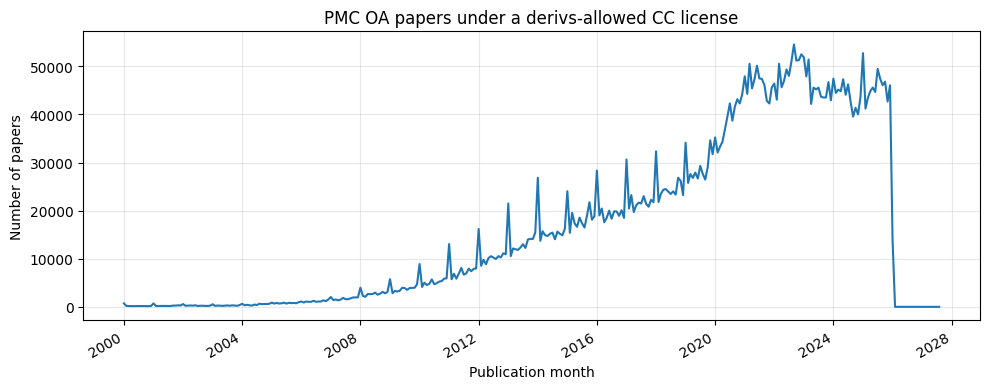

In [ ]:
YEAR_MIN = 2000
c = Counter()
bin_counts: Counter[date] = Counter()
n_skipped = 0
for x in data:
    if not any(
        license.startswith("creativecommons") and "nd" not in license.split()
        for license in x["normalised_licenses"]
    ):
        continue
    pd = x.get("pub_date") or {}
    year, month = pd.get("year"), pd.get("month")
    if month is None:
        month = 1
    if (
        year is None
        or month is None
        or not (YEAR_MIN <= year)
        or not (1 <= month <= 12)
    ):
        n_skipped += 1
        c[date(year, month, 1)] += 1
        continue
    bin_counts[date(year, month, 1)] += 1

print(f"Derivs-allowed papers plotted: {sum(bin_counts.values()):,}")
print(f"Derivs-allowed papers skipped (missing/out-of-range year or month): {n_skipped:,}")

months = sorted(bin_counts)
counts = [bin_counts[m] for m in months]

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(months, counts)
ax.set_xlabel("Publication month")
ax.set_ylabel("Number of papers")
ax.set_title("PMC OA papers under a derivs-allowed CC license")
ax.grid(alpha=0.3)
fig.autofmt_xdate()
fig.tight_layout()
plt.show()